# AI-ML Assignment 7

## Cart-Pole Reinforcement Learning Agent Training

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Environment Setup

In [1]:
!pip install gymnasium[classic-control]
!pip install pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.3 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
env = gym.make("CartPole-v1")

print("Environment Created Successfully!")

Environment Created Successfully!


In [4]:
print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Action Space:
Discrete(2)


In [5]:
state, info = env.reset()

print("Initial State:")

print(state)

Initial State:
[ 0.03364002  0.02859209 -0.04095349 -0.02751161]


In [6]:
state, info = env.reset()

for step in range(10):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step+1}")
    print("Action:", action)
    print("Reward:", reward)
    print("Next State:", next_state)

    if terminated or truncated:
        print("Episode Finished")
        break

Step 1
Action: 0
Reward: 1.0
Next State: [-0.00031874 -0.23014264 -0.01271999  0.28488278]
Step 2
Action: 0
Reward: 1.0
Next State: [-0.0049216  -0.4250809  -0.00702234  0.5735269 ]
Step 3
Action: 0
Reward: 1.0
Next State: [-0.01342321 -0.62010366  0.0044482   0.86398935]
Step 4
Action: 0
Reward: 1.0
Next State: [-0.02582529 -0.8152859   0.02172799  1.1580676 ]
Step 5
Action: 1
Reward: 1.0
Next State: [-0.04213101 -0.6204538   0.04488934  0.8722759 ]
Step 6
Action: 0
Reward: 1.0
Next State: [-0.05454008 -0.8161565   0.06233486  1.1787273 ]
Step 7
Action: 1
Reward: 1.0
Next State: [-0.07086321 -0.6218969   0.0859094   0.9062184 ]
Step 8
Action: 1
Reward: 1.0
Next State: [-0.08330115 -0.42803666  0.10403378  0.6417268 ]
Step 9
Action: 0
Reward: 1.0
Next State: [-0.09186188 -0.6244432   0.11686831  0.96527445]
Step 10
Action: 1
Reward: 1.0
Next State: [-0.10435075 -0.43106845  0.1361738   0.7114721 ]


# Task 2: Agent Training

In [7]:
# Q-Learning Parameters

learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 500

# Initialize an empty Q-table
q_table = {}

In [8]:
def get_state(state):
    # Convert continuous state to a rounded tuple
    return tuple(np.round(state, 1))

In [9]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()
    state = get_state(state)

    total_reward = 0
    done = False

    while not done:

        # Initialize state if new
        if state not in q_table:
            q_table[state] = np.zeros(env.action_space.n)

        # Epsilon-Greedy Action Selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state = get_state(next_state)

        if next_state not in q_table:
            q_table[next_state] = np.zeros(env.action_space.n)

        # Q-Learning Update
        q_table[state][action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)

print("Training Completed Successfully!")

Training Completed Successfully!


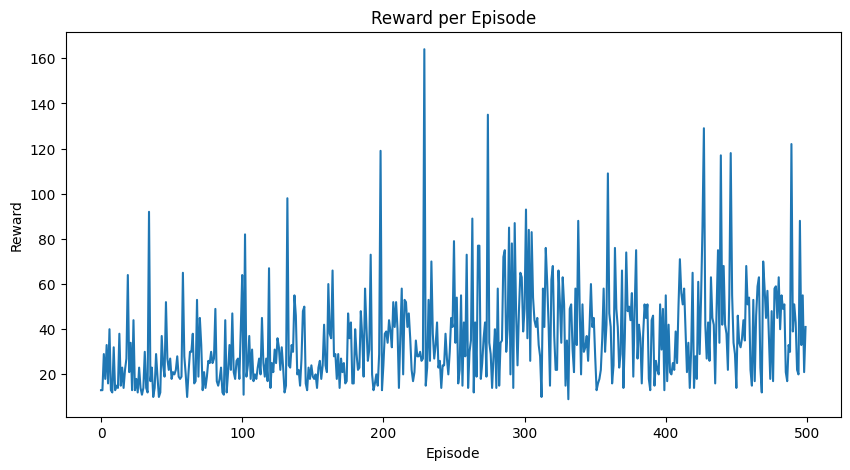

In [10]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.show()

# Task 3: Agent Testing

In [11]:
test_rewards = []

for episode in range(10):

    state, info = env.reset()
    state = get_state(state)

    total_reward = 0
    done = False

    while not done:

        if state not in q_table:
            q_table[state] = np.zeros(env.action_space.n)

        # Choose the best learned action
        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        state = get_state(next_state)

        total_reward += reward

    test_rewards.append(total_reward)

print("Testing Completed Successfully!")

Testing Completed Successfully!


In [12]:
print("Rewards in Test Episodes:")

print(test_rewards)

print("\nAverage Reward:", np.mean(test_rewards))

Rewards in Test Episodes:
[14.0, 42.0, 48.0, 37.0, 43.0, 57.0, 29.0, 19.0, 65.0, 31.0]

Average Reward: 38.5


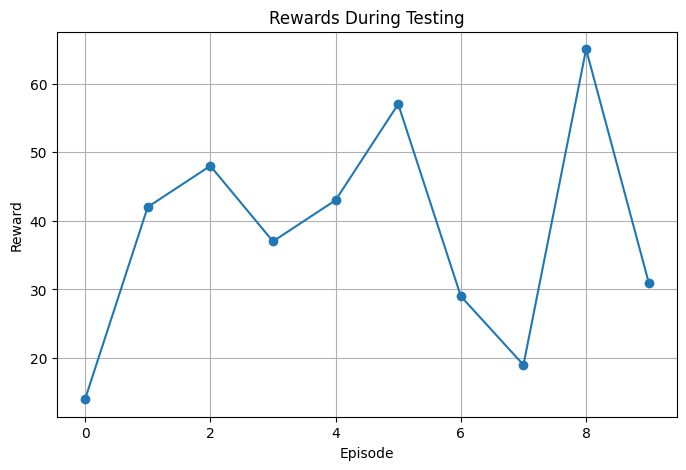

In [13]:
plt.figure(figsize=(8,5))

plt.plot(test_rewards, marker='o')

plt.title("Rewards During Testing")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Task 4: Model Evaluation

In [14]:
# Calculate Performance Metrics

average_reward = np.mean(test_rewards)
maximum_reward = np.max(test_rewards)
minimum_reward = np.min(test_rewards)

print("Average Reward :", average_reward)
print("Maximum Reward :", maximum_reward)
print("Minimum Reward :", minimum_reward)

Average Reward : 38.5
Maximum Reward : 65.0
Minimum Reward : 14.0


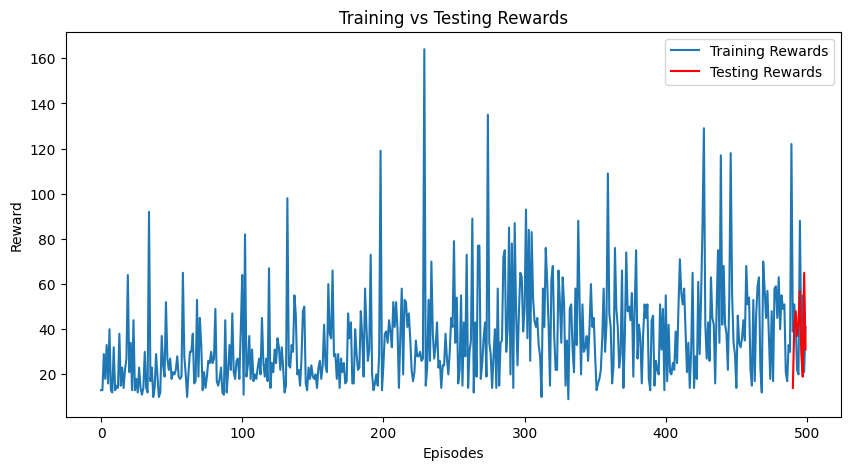

In [15]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards, label="Training Rewards")
plt.plot(
    range(len(episode_rewards)-len(test_rewards), len(episode_rewards)),
    test_rewards,
    label="Testing Rewards",
    color="red"
)

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Training vs Testing Rewards")
plt.legend()

plt.show()

## Observations

1. The reinforcement learning agent improved its performance over time by learning from interactions with the CartPole environment.

2. The average reward increased during training, indicating that the Q-learning algorithm successfully learned a better policy.

3. Although the agent performed well on most test episodes, performance may vary because of the exploration strategy and the limited number of training episodes.

# Task 5: Conclusion

The CartPole Reinforcement Learning agent was successfully developed and trained using the Q-learning algorithm. During training, the agent interacted with the environment, learned from rewards, and gradually improved its decision-making ability. The increasing reward values demonstrated that the agent learned to balance the pole more effectively over multiple episodes. Testing showed that the trained agent could achieve consistent performance by selecting optimal actions. However, Q-learning has limitations when dealing with continuous and high-dimensional state spaces, as it relies on state discretization. More advanced reinforcement learning methods such as Deep Q-Networks (DQN) can overcome this limitation and achieve better performance in complex environments.